In [ ]:
# proportion of each cell type in each niche

In [3]:
# %% Libraries
import os
import squidpy as sq
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
#import novae
import matplotlib.pyplot as plt
import rapids_singlecell as rsc

import os
#import plotnine as p9

# %% Setting Paths
MAIN_DIR_NAME = "cosmx_cf_proseg"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'cellcharter'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Load the object
comb = sc.read_h5ad(CUR_OBJ_PATH)


In [4]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

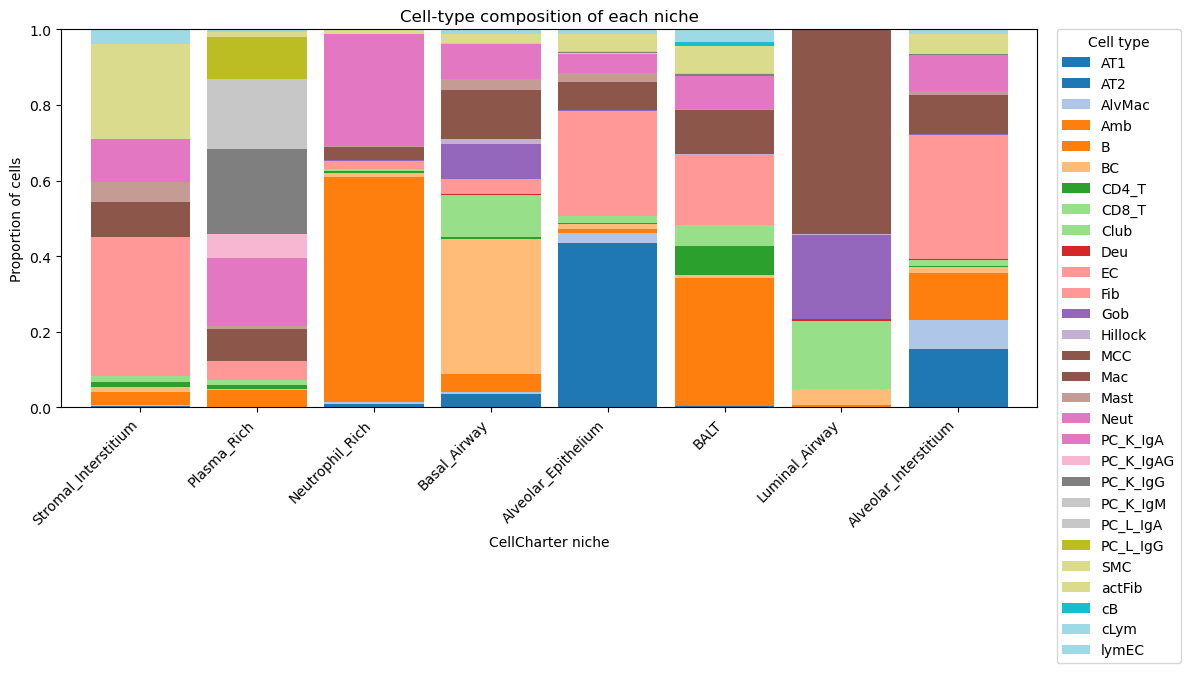

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# If you have not loaded the object yet:
# import scanpy as sc
# comb = sc.read_h5ad("comb.h5ad")

niche_col = "cellcharter_niches"
celltype_col = "ann_lvl_3_refined"

# Count cells of each type in each niche
counts = pd.crosstab(
    comb.obs[niche_col],
    comb.obs[celltype_col],
)

# Divide by the total number of cells in each niche
proportions = counts.div(counts.sum(axis=1), axis=0)

ax = proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.85,
    colormap="tab20",
)

ax.set_xlabel("CellCharter niche")
ax.set_ylabel("Proportion of cells")
ax.set_ylim(0, 1)
ax.set_title("Cell-type composition of each niche")
ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

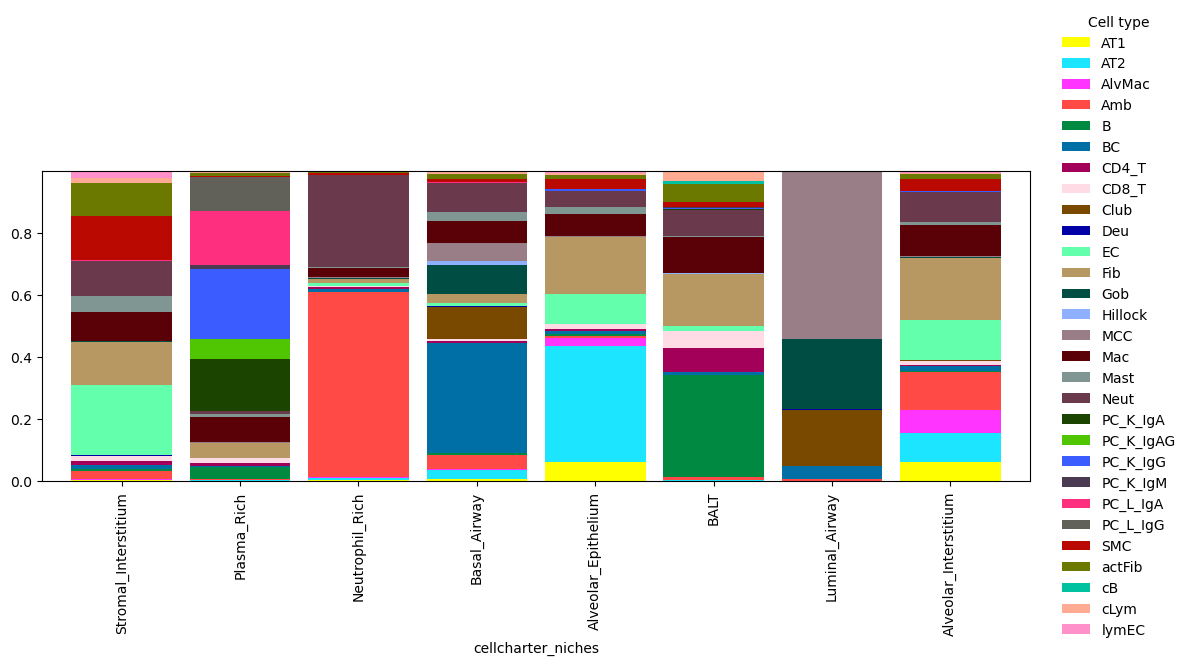

In [7]:
celltype_col = "ann_lvl_3_refined"
palette_key = f"{celltype_col}_colors"

categories = comb.obs[celltype_col].cat.categories
saved_colors = comb.uns[palette_key]

color_map = dict(zip(categories, saved_colors))
bar_colors = [color_map[celltype] for celltype in proportions.columns]

ax = proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.85,
    color=bar_colors,
)

ax.legend(
    title="Cell type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
plt.tight_layout()

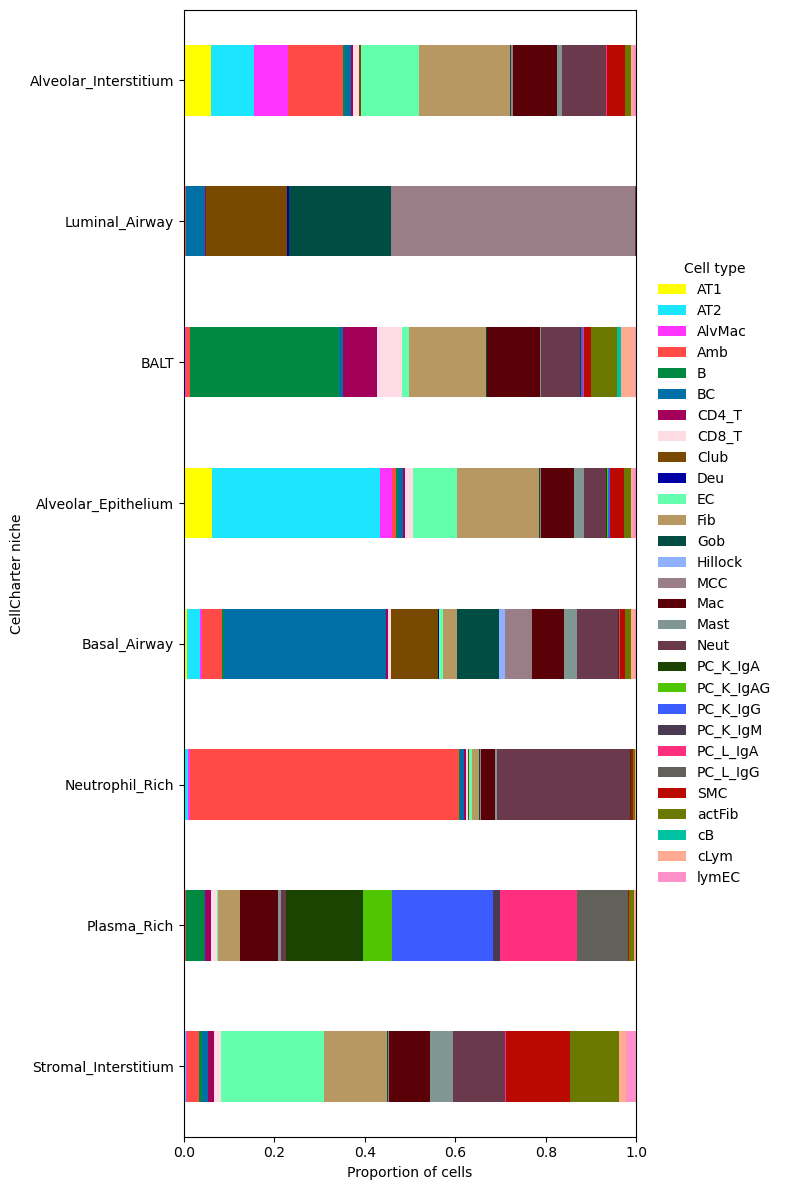

In [13]:
ax = proportions.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 12),
    color=bar_colors,
)

ax.set_xlabel("Proportion of cells")
ax.set_ylabel("CellCharter niche")
ax.set_xlim(0, 1)
ax.legend(
    title="Cell type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.tight_layout()
plt.show()

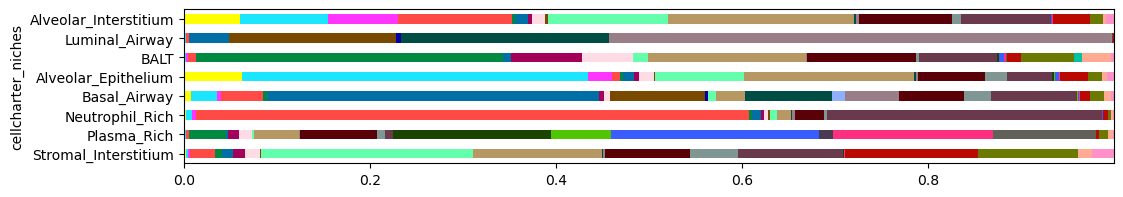

In [14]:
ax = proportions.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 2),
    color=bar_colors,
    legend=False,
)